# Mask Detection On Fine Tuning YOLOV26

In [ ]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
api_key = user_secrets.get_secret("MASK DATASET YOLO")

# Load Dataset

In [5]:
from roboflow import Roboflow
rf = Roboflow(api_key=api_key)
project = rf.workspace("belajar-yolo-dlwtw").project("mask-wearing-eyils")
version = project.version(1)
dataset = version.download("yolo26")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Mask-Wearing-1 in yolo26:: 100%|██████████| 9335/9335 [00:00<00:00, 10474.67it/s]


# Load Model

In [6]:
from ultralytics import YOLO

model = YOLO("yolo26m.pt")  # pass any model type

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


# Train Model

In [7]:
results = model.train(optimizer="AdamW", lr0=0.01, data=f"{dataset.location}/data.yaml", epochs=25)

Ultralytics 8.4.78 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/Mask-Wearing-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimize

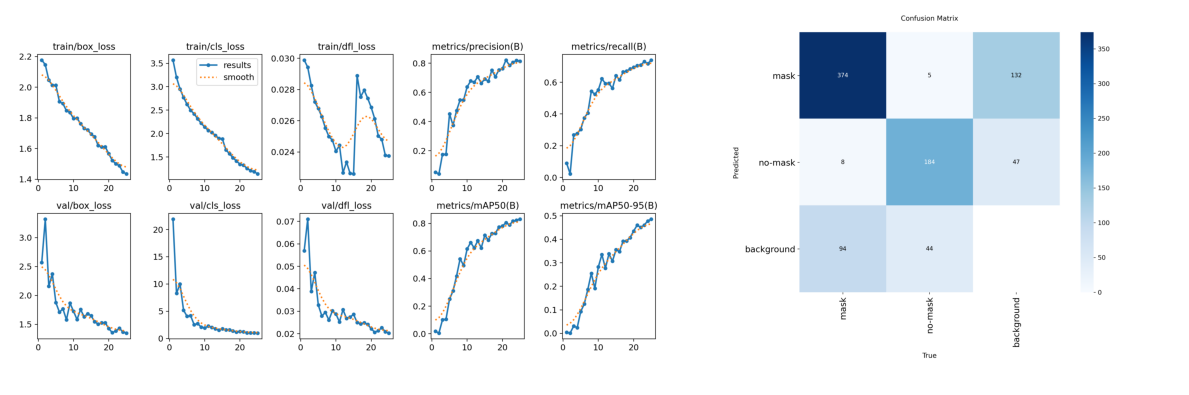

In [5]:
from PIL import Image
import matplotlib.pyplot as plt

# Load images
img1 = Image.open('image.png')
img2 = Image.open('confusion_matrix.png')

# Buat figure dengan 1 baris, 2 kolom, kolom pertama lebih lebar
fig, axes = plt.subplots(1, 2, figsize=(12, 6), gridspec_kw={'width_ratios': [1.7, 1.3]})

# Plot gambar pertama (lebih besar)
axes[0].imshow(img1)
axes[0].axis("off")

# Plot gambar kedua (lebih kecil)
axes[1].imshow(img2)
axes[1].axis("off")

plt.tight_layout()
plt.show()


# Evaluation

In [8]:
best = YOLO('runs/detect/train/weights/best.pt')

In [11]:
metrics = best.val(data=f"{dataset.location}/data.yaml", split='test')

Ultralytics 8.4.78 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 932.4±311.3 MB/s, size: 24.0 KB)
val: Scanning /kaggle/working/Mask-Wearing-1/test/labels.cache... 200 images, 35 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 200/200 93.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 2.1it/s 6.1s0.4s
                   all        200        377      0.871      0.792      0.852      0.506
                  mask         98        288      0.868      0.753      0.823      0.435
               no-mask         77         89      0.874      0.831      0.882      0.577
Speed: 1.7ms preprocess, 24.8ms inference, 0.0ms loss, 0.1ms postprocess per image
Results saved to /kaggle/working/runs/detect/val-2


In [12]:
# Menampilkan hasil metrik secara spesifik
print(f"mAP50-95: {metrics.box.map}") # Mean Average Precision di rentang IoU 0.50-0.95
print(f"mAP50: {metrics.box.map50}")  # Mean Average Precision di IoU 0.50
print(f"Precision: {metrics.box.p}")
print(f"Recall: {metrics.box.r}")

mAP50-95: 0.5061447069862594
mAP50: 0.8521697355871639
Precision: [    0.86794     0.87387]
Recall: [    0.75307     0.83146]


# Inference

In [13]:
predicts = best.predict(source=f"{dataset.location}/test/images")


image 1/200 /kaggle/working/Mask-Wearing-1/test/images/0209-00176-076b1_jpg.rf.a5410daed9fd534e52497fb692b9defa.jpg: 640x640 3 masks, 1 no-mask, 37.5ms
image 2/200 /kaggle/working/Mask-Wearing-1/test/images/0450908675_50159485_mutation-virus-chine-inquietude_jpg.rf.4d67f3bc8b83a28b2e18b52d436bd5cc.jpg: 640x640 2 masks, 2 no-masks, 37.5ms
image 3/200 /kaggle/working/Mask-Wearing-1/test/images/0_Concern-In-China-As-Mystery-Virus-Spreads_jpg.rf.1617e7fe45beadbb01e3fbfbdbace997.jpg: 640x640 2 masks, 37.5ms
image 4/200 /kaggle/working/Mask-Wearing-1/test/images/0_Concern-In-China-As-Mystery-Virus-Spreads_jpg.rf.8fc4e6baa528d4c0ca7063aca93d2da6.jpg: 640x640 2 masks, 37.5ms
image 5/200 /kaggle/working/Mask-Wearing-1/test/images/1224331650_g_400-w_g_jpg.rf.6b46c3e9aa77fda33ea46500e956299a.jpg: 640x640 3 masks, 24.9ms
image 6/200 /kaggle/working/Mask-Wearing-1/test/images/1224331650_g_400-w_g_jpg.rf.ee36b13a38263d82214b918c5b8837a5.jpg: 640x640 3 masks, 23.6ms
image 7/200 /kaggle/working/Mask-

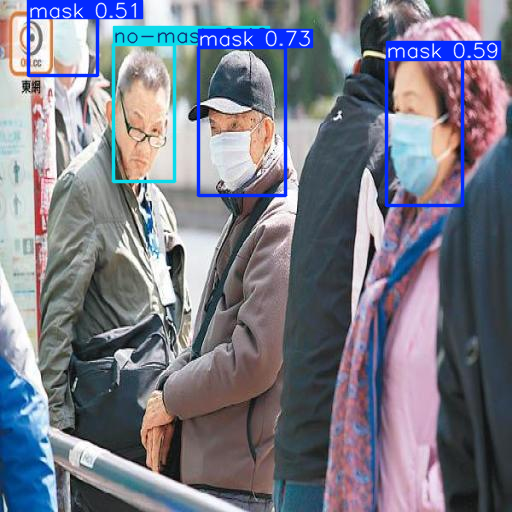

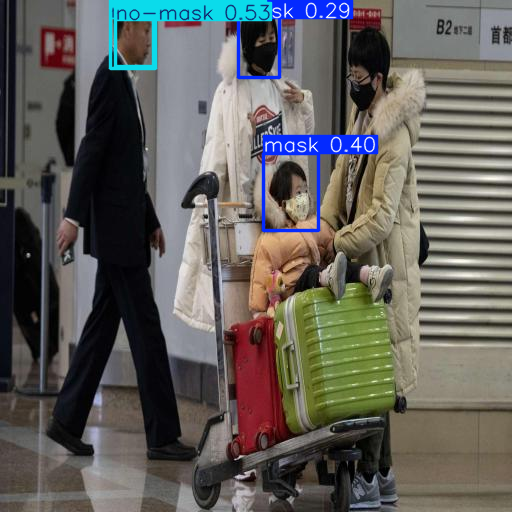

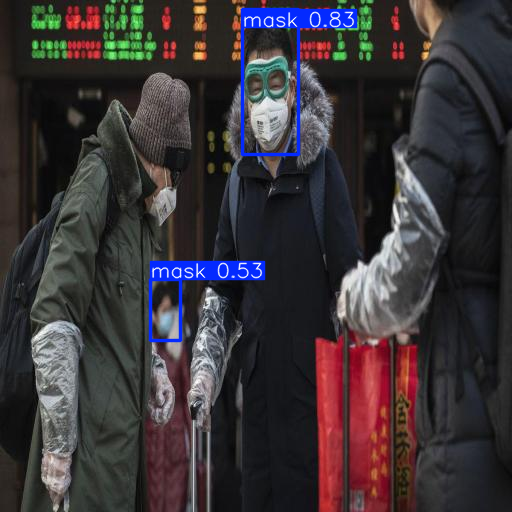

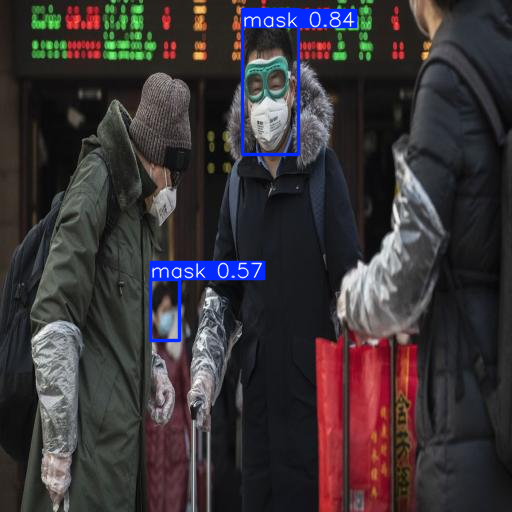

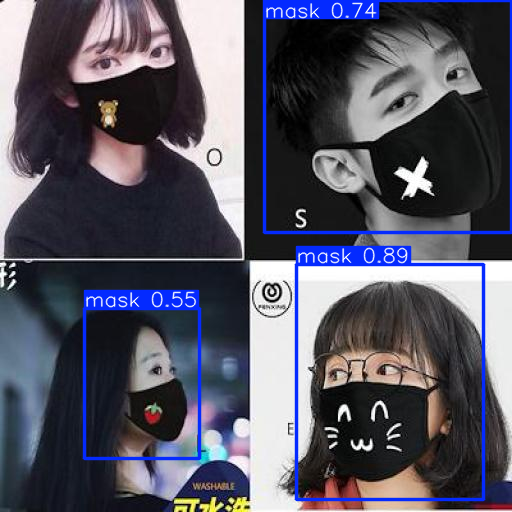

In [14]:
for predict in predicts[:5]:
    predict.show()